In [1]:
import requests
import configparser

In [158]:
from PIL import Image
from io import BytesIO
import matplotlib.pyplot as plt
from utils import plot_image
import numpy as np
from rasterio.io import MemoryFile
import datetime

In [2]:

config_file = configparser.ConfigParser()
config_file.read("config.ini")

username = config_file["copernicus"]["username"]
password = config_file["copernicus"]["password"]

In [25]:
def get_access_token(username: str, password: str) -> str:
    # Prepare the data for the token request
    data = {
        "client_id": "cdse-public",
        "username": username,
        "password": password,
        "grant_type": "password",
    }
    
    # Send the request to get the access token
    try:
        r = requests.post(
            "https://identity.dataspace.copernicus.eu/auth/realms/CDSE/protocol/openid-connect/token",
            data=data,
        )
        r.raise_for_status()
        access_token = r.json().get("access_token")
        if not access_token:
            raise ValueError("No access token found in response.")
        return access_token
    except requests.exceptions.RequestException as e:
        print(f"Request failed: {e}")
        return None

# Retrieve the token
access_token = get_access_token(username, password)

In [100]:
## PARA IMAGEN

access_token = get_access_token(username, password)


In [223]:
start = datetime.datetime(2022, 7, 1).date().isoformat()

end = datetime.datetime(2022, 7, 20).date().isoformat()
print(start)
print(end)
time_interval = [start, end]

2022-07-01
2022-07-20


In [224]:
def get_image_copernicus(access_token, time_interval, image_type, evalscript): 
    identifier = ""
    if image_type == "png": 
        identifier = "default"
    elif image_type == "tiff":
        identifier = "index"
    url = "https://sh.dataspace.copernicus.eu/api/v1/process"

    headers={
    "Content-Type": "application/json",
    "Authorization" : "Bearer "+ access_token
    }

    json={
        "input": {
            "bounds": {
                "bbox": [
                    -0.866977,
                    37.628916,
                    -0.71696,
                    37.822802
                    ]
            },
            "data": [
                {
                "dataFilter": {
                    "timeRange": {
                    "from": time_interval[0] + "T00:00:00Z", #"2024-10-12T00:00:00Z", #YYYY-mm-dd
                    "to": time_interval[1] + "T23:59:59Z"#"2024-11-12T23:59:59Z"
                    },
                    "mosaickingOrder": "leastCC"
                
                },
                "type": "sentinel-2-l2a"
                }]
        },
        "output": {
            "width": 1323,
            "height": 2158,

            "responses": [
                {
                    "identifier": identifier,
                    "format": {
                        "type": "image/" + image_type
                    }
                }
            ]
        },
        "evalscript" : evalscript
    }

    response = requests.post(url, headers=headers, json=json)

    if response.status_code == 200:
        print(f"Request completed")
        return response 
    else:
        print(f"Request failed {response.content}")
        return None


In [146]:
## PARA ARRAY 2D

access_token = get_access_token(username, password)

url = "https://sh.dataspace.copernicus.eu/api/v1/process"

headers={
  "Content-Type": "application/json",
  "Authorization" : "Bearer "+ access_token
}

json={
    "input": {
        "bounds": {
            "bbox": [
                -0.866977,
                37.628916,
                -0.71696,
                37.822802
                ]
        },
        "data": [
            {
            "dataFilter": {
                "timeRange": {
                  "from": "2024-10-12T00:00:00Z", #YYYY-mm-dd
                  "to": "2024-11-12T23:59:59Z"
                },
                "mosaickingOrder": "leastCC"
            
            },
            "type": "sentinel-2-l2a"
            }]
    },
    "output": {
        "width": 1323,
        "height": 2158,
        # "width": 130,
        # "height": 215,
        # "resx": 1, # Cómo hacer para tener un pixel en la imagen con la misma resolución que las capta el satélite (de 10 x 10 m)
        # "resy": 1,
        "responses": [
            {
                "identifier": "default",
                "format": {
                    "type": "image/tiff"
                }
            }
        ]
    },
    "evalscript" :
    """
        //VERSION=3
        function setup() {
            return {
                input: ["B03", "B08"],
                output: {
                    id: "default",       // Identifier for the output
                    bands: 1,
                    sampleType: "FLOAT32"
                }
            }
        }

        function evaluatePixel(samples) {
            return [index(samples.B03, samples.B08)]
        }
     """
}

In [191]:
access_token = get_access_token(username, password)
evalscript = """
    //VERSION=3

    function setup() {
        return {
            input: ["B03", "B08"],
            output: {
                id: "index",       // Identifier for the output
                bands: 1,
                sampleType: "FLOAT32"
            }
        }
    }

    function evaluatePixel(samples) {
        return [index(samples.B03, samples.B08)]
    }
    """
image_type = "tiff" # png para imagen / tiff para array - depende del evalscript
response = get_image_copernicus(access_token, time_interval, image_type, evalscript)

Request completed


In [225]:
access_token = get_access_token(username, password)

evalscript = """
    //VERSION=3

    var indexNumber = 0;
    var minValue = 0;
    var maxValue = 30;

    // Color Scale
    //var scaleLimits = [0, 5, 10, 20, 30]; // Define the borders
    var scaleLimits = [minValue, (maxValue + 3 * minValue) / 4, (maxValue + minValue) / 2, (3 * maxValue + minValue) / 4, maxValue]
    var s = 255; // Values range from 0 to 255 for every color channel
    var colorScale =  // Define the RGB colors for each border
    [
        [0 / s, 0 / s, 255 / s], // Blue
        [0 / s, 255 / s, 255 / s], // Cyan
        [0 / s, 255 / s, 0 / s], // Green
        [255 / s, 255 / s, 0 / s], // Yellow
        [255 / s, 0 / s, 0 / s], // Red
    ];

      
    function setup() {
        return {
            input: ["B01", "B02", "B03", "B04", "B05", "B06", "B07", "B08", "SCL", "dataMask"],
            output: [
                { id: "default", bands: 3 },
                { id: "index", bands: 1, sampleType: "FLOAT32" },
                { id: "dataMask", bands: 1 }
            ]
        }
    }

    function evaluatePixel(samples) {
        let NDWI = index(samples.B03, samples.B08); 
        let TrueColor = [samples.B04 * 2.5, samples.B03 * 2.5, samples.B02 * 2.5];   

        let index0 = 14.039 + (86.11 * (samples.B05 - samples.B04) / (samples.B05 + samples.B04)) + (194.325 * Math.pow((samples.B05 - samples.B04) / (samples.B05 + samples.B04), 2));
        let viz0 = colorBlend(index0, scaleLimits, colorScale);

        
        let imgVals = null;
        let val = NaN;

        if (NDWI < -0) { // If NDWI is lower than 0 is not water, so return  true color
        imgVals = [...TrueColor, samples.dataMask];
        } else { // Evaluate indexNumber
        switch (indexNumber) {
            case 0: // indexNumber = 0
            imgVals = [...viz0, samples.dataMask];
            val = index0;
            break;
            case 1: // indexNumber = 1
            imgVals = [...viz1, samples.dataMask];
            val = index1;
            break;
        }
        }

        const indexVal = samples.dataMask === 1 ? val : NaN;

        return {
            default: imgVals,
            index: [indexVal],
            dataMask: [samples.dataMask]
        };
    }
    """
image_type = "png" # png para imagen / tiff para array - depende del evalscript
response = get_image_copernicus(access_token, time_interval, image_type, evalscript)

Request completed


In [220]:
if response.status_code == 200:
    # Open the TIFF data directly from the response content using a MemoryFile
    with MemoryFile(response.content) as memfile:
        with memfile.open() as src:
            index_array = src.read(1)  # Read the first band as a NumPy array

    # Now `index_array` is a NumPy array containing the index values for each pixel
    print(index_array)
else:
    print(f"Request failed with status code: {response.status_code}")
    

[[123  79  42 ...   0   0   0]
 [104  91  31 ...   0   0   0]
 [ 66 103  55 ...   0   0   0]
 ...
 [173 177 140 ...  99  72  49]
 [151 134 105 ...  91  59  54]
 [114  80  85 ...  89  61  54]]


/home/antonio/.pyenv/versions/3.8.5/envs/nitrates/lib/python3.8/site-packages/rasterio/io.py:138: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  return DatasetReader(mempath, driver=driver, sharing=sharing, **kwargs)


In [221]:
index_array.shape

(2158, 1323)

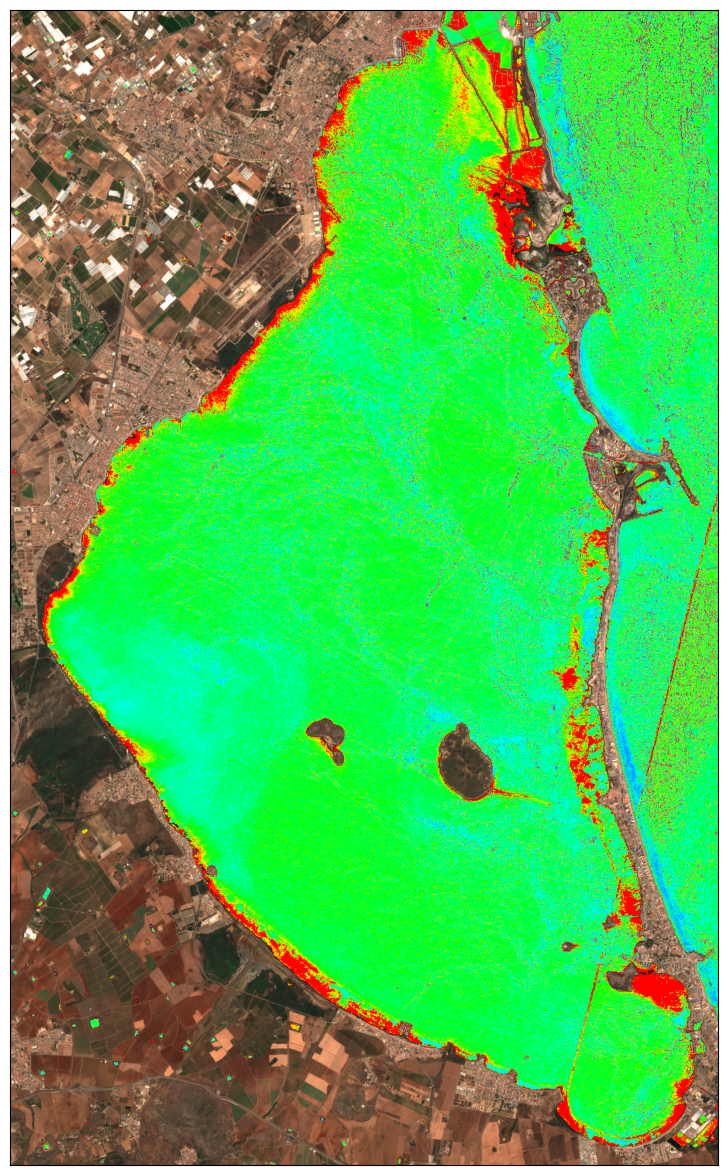

In [226]:
image = Image.open(BytesIO(response.content))
image_np = np.array(image, dtype=np.float32)  # Convert to float for scaling

# Use your `plot_image` function with a brightness factor and clipping range
plot_image(image_np, factor=1 / 255, clip_range=(-1, 1))